In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load the results CSV
# csv_path = "/export/scratch/mickler/boa_models/test/runs/109_test___limit_test_batches-20__from_checkpoint___export_scratch_mklockow_boa_data_qmugs_pyscf_data__test-1___export_scratch_mklockow_boa_data_qmugs_pyscf_datasplits.json__qm9_pyscf_small_from_/expo/tensorboard/version_0/results.csv"
# csv_path = "/export/scratch/mklockow/boa/models/test/runs/249_test___limit_test_batches-20__from_checkpoint_528___export_scratch_mklockow_boa_data_qmugs_pyscf_llbox_data___export_scratch_mklockow_boa_data_qmugs_pyscf_llbox_datasplits.json__qm9_pyscf_small_from_528/tensorboard/version_0/results.csv"
# csv_path = "/export/scratch/mklockow/boa/models/test/runs/273_test___limit_test_batches-20__from_checkpoint__gth-tzv2p___export_scratch_mklockow_boa_data_qmugs_pyscf_data___export_scratch_mklockow_boa_data_qmugs_pyscf_datasplits.json__qm9_pyscf_small_from_/expo/tensorboard/version_0/results.csv"
resnet_csv_path = "/export/scratch/mklockow/boa/data/qmugs_pyscf/resnet_results.csv"
resnet_init_csv_path = "/export/scratch/mklockow/boa/data/qmugs_pyscf/new_sad_timings.csv"
# resnet_csv_path = "/export/scratch/mickler/boa_models/test/runs/109_test___limit_test_batches-20__from_checkpoint___export_scratch_mklockow_boa_data_qmugs_pyscf_data__test-1___export_scratch_mklockow_boa_data_qmugs_pyscf_datasplits.json__qm9_pyscf_small_from_/expo/tensorboard/version_0/results.csv"
# csv_path = "/export/scratch/mklockow/boa/models/test/runs/317_test___limit_test_batches-20__from_checkpoint___export_scratch_mklockow_boa_data_qmugs_pyscf_data___export_scratch_mklockow_boa_data_qmugs_pyscf_datasplits.json__qm9_pyscf_small_small_cutoff__max_n_probe_per_pass-90000_from_/expo/tensorboard/version_0/results.csv"
# csv_path = "/export/scratch/mklockow/boa/models/test/runs/351_test___limit_test_batches-20__from_checkpoint_556___export_scratch_mklockow_boa_data_qmugs_pyscf_data___export_scratch_mklockow_boa_data_qmugs_pyscf_datasplits.json__qm9_pyscf_small_small_cutoff__max_n_probe_per_pass-90000_from_556/tensorboard/version_0/results.csv"
csv_path = "/export/scratch/mklockow/boa/models/test/runs/360_test___limit_test_batches-20__from_checkpoint_556___export_scratch_mklockow_boa_data_qmugs_pyscf_data___export_scratch_mklockow_boa_data_qmugs_pyscf_datasplits.json__qm9_pyscf_small_small_cutoff__max_n_probe_per_pass-60000_from_556/tensorboard/version_0/results.csv"
csv_path_large_cutoff = "/export/scratch/mklockow/boa/models/test/runs/311_test___limit_test_batches-20__from_checkpoint_491___export_scratch_mklockow_boa_data_qmugs_pyscf_data___export_scratch_mklockow_boa_data_qmugs_pyscf_datasplits.json__qm9_pyscf_small_from_491/tensorboard/version_0/results.csv"

df = pd.read_csv(csv_path)
df_large_cutoff = pd.read_csv(csv_path_large_cutoff)

print(f"Loaded small cutoff data with {len(df)} rows")
print(f"Loaded large cutoff data with {len(df_large_cutoff)} rows")
print(f"\nColumns (keys):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

print(f"\nFirst few rows (small cutoff):")
print(df.head())

df_resnet = pd.read_csv(resnet_csv_path)
print(f"\nResNet Loaded data with {len(df_resnet)} rows")
print(f"\nResNet Columns (keys):")
for i, col in enumerate(df_resnet.columns, 1):
    print(f"  {i}. {col}")

# A100 node with 8 threads AMD EPYC 7452
print(f"\nResNet First few rows:")
print(df_resnet.head())

# Merge with initial SAD timings
df_init = pd.read_csv(resnet_init_csv_path)

# Merge dataframes on 'id' to ensure correct matching
df = df.merge(df_resnet[['id', 'nmape', 'time']], on='id', how='inner', suffixes=('', '_resnet'))
df = df.merge(df_init[['id', 'time']], on='id', how='inner', suffixes=('', '_init'))

df_large_cutoff = df_large_cutoff.merge(df_resnet[['id', 'nmape', 'time']], on='id', how='inner', suffixes=('', '_resnet'))
df_large_cutoff = df_large_cutoff.merge(df_init[['id', 'time']], on='id', how='inner', suffixes=('', '_init'))

print(f"\nMerged small cutoff data with {len(df)} rows")
print(f"Merged large cutoff data with {len(df_large_cutoff)} rows")
print(f"\nMerged columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")
print(f"\nFirst few rows after merge (small cutoff):")
df.head()


Loaded small cutoff data with 17 rows
Loaded large cutoff data with 17 rows

Columns (keys):
  1. dataset_idx
  2. id
  3. nmape
  4. num_atoms
  5. num_electrons
  6. time

First few rows (small cutoff):
   dataset_idx        id     nmape  num_atoms  num_electrons       time
0            0   7117199  0.387225        194            730  32.505883
1            0   9863572  0.474081         37            146   5.946818
2            0  10243860  0.405705        175            684  22.819555
3            0  10935827  0.352432        111            428  12.640735
4            0  10935928  0.357757        117            452  10.648840

ResNet Loaded data with 17 rows

ResNet Columns (keys):
  1. dataset_idx
  2. id
  3. nmape
  4. num_electrons
  5. time

ResNet First few rows:
   dataset_idx        id     nmape  num_electrons      time
0            0  10243860  0.006920      73.500687  0.114018
1            1  10935827  0.004887      45.938137  0.024102
2            2  10935928  0.004998   

,dataset_idx,id,nmape,num_atoms,num_electrons,time,nmape_resnet,time_resnet,time_init
0,0,7117199,0.387225,194,730,32.505883,0.009928,0.048965,66.567802
1,0,9863572,0.474081,37,146,5.946818,0.002936,0.023346,2.016222
2,0,10243860,0.405705,175,684,22.819555,0.006920,0.114018,104.479599
3,0,10935827,0.352432,111,428,12.640735,0.004887,0.024102,13.603644
4,0,10935928,0.357757,117,452,10.648840,0.004998,0.023206,15.963648


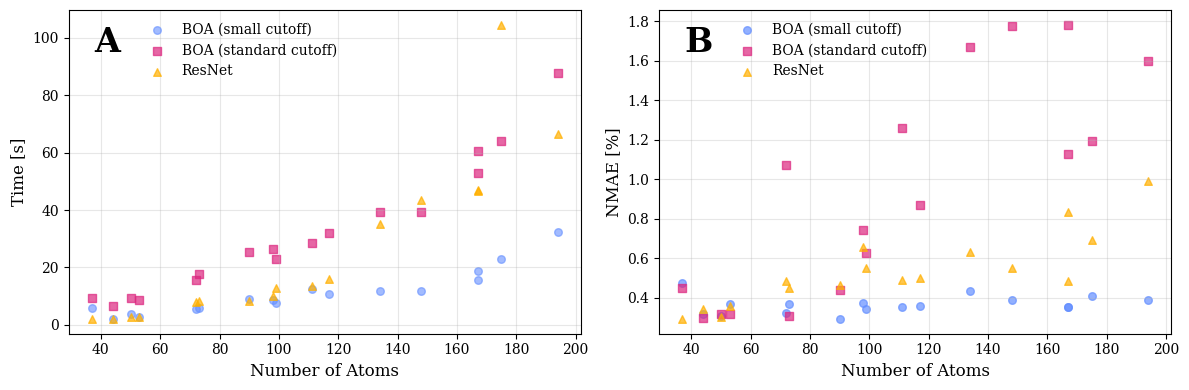


Statistics (Small Cutoff):
Time:
  Mean: 11.0799 s
  Median: 8.8542 s
  Min: 2.0746 s
  Max: 32.5059 s

NMAE:
  Mean: 0.363878
  Median: 0.357757
  Min: 0.291057
  Max: 0.474081

Statistics (Large Cutoff):
Time:
  Mean: 32.1699 s
  Median: 26.3427 s
  Min: 6.4231 s
  Max: 87.6697 s

NMAE:
  Mean: 0.931610
  Median: 0.871324
  Min: 0.297486
  Max: 1.782513

Statistics (ResNet):
Time (including initialization):
  Mean: 25.2584 s
  Median: 12.7021 s
  Min: 2.0396 s
  Max: 104.5936 s

NMAE:
  Mean: 0.533547 %
  Median: 0.488689 %
  Min: 0.293586 %
  Max: 0.992810 %

Number of Atoms:
  Mean: 107.6
  Median: 99.0
  Min: 37
  Max: 194


In [4]:
import matplotlib.pyplot as plt

# Explicitly disable LaTeX and set font to match LaTeX style
# plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif', 'Times New Roman', 'serif']

# IBM colorblind-safe palette
ibm_colors = {
    'blue': '#648FFF',
    'purple': '#785EF0',
    'magenta': '#DC267F',
    'orange': '#FE6100',
    'yellow': '#FFB000'
}

# Create scatter plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
alpha = 0.7
size = 30

# Plot 1: Time vs num_atoms
ax = axes[0]
ax.scatter(df['num_atoms'], df['time'], alpha=0.6, s=size, label='BOA (small cutoff)', color=ibm_colors['blue'], marker='o')
ax.scatter(df_large_cutoff['num_atoms'], df_large_cutoff['time'], alpha=alpha, s=size, label='BOA (standard cutoff)', color=ibm_colors['magenta'], marker='s')
ax.scatter(df['num_atoms'], df['time_resnet'] + df['time_init'], alpha=alpha, s=size, label='ResNet', color=ibm_colors['yellow'], marker='^')
ax.set_xlabel('Number of Atoms', fontsize=12)
ax.set_ylabel('Time [s]', fontsize=12)
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, 'A', transform=ax.transAxes, fontsize=24, fontweight='bold', va='top')
# ax.set_yscale('log')

# # Add trend line
# z = np.polyfit(df['num_atoms'], df['time'], 1)
# p = np.poly1d(z)
# ax.plot(df['num_atoms'].sort_values(), p(df['num_atoms'].sort_values()), 
#         "r--", alpha=0.8, label=f'Linear fit: y={z[0]:.2f}x+{z[1]:.2f}')
ax.legend(loc='upper left', bbox_to_anchor=(0.12, 1.0), frameon=False)

# Plot 2: NMAPE vs num_atoms
ax = axes[1]
ax.scatter(df['num_atoms'], df['nmape'], alpha=alpha, s=size, label='BOA (small cutoff)', color=ibm_colors['blue'], marker='o')
ax.scatter(df_large_cutoff['num_atoms'], df_large_cutoff['nmape'], alpha=alpha, s=size, label='BOA (standard cutoff)', color=ibm_colors['magenta'], marker='s')
ax.scatter(df['num_atoms'], df['nmape_resnet']*100, alpha=alpha, s=size, label='ResNet', color=ibm_colors['yellow'], marker='^')
ax.set_xlabel('Number of Atoms', fontsize=12)
ax.set_ylabel('NMAE [%]', fontsize=12)
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, 'B', transform=ax.transAxes, fontsize=24, fontweight='bold', va='top')
ax.legend(loc='upper left', bbox_to_anchor=(0.12, 1.0), frameon=False)

plt.tight_layout()
plt.show()

# Print statistics
print("\nStatistics (Small Cutoff):")
print(f"Time:")
print(f"  Mean: {df['time'].mean():.4f} s")
print(f"  Median: {df['time'].median():.4f} s")
print(f"  Min: {df['time'].min():.4f} s")
print(f"  Max: {df['time'].max():.4f} s")

print(f"\nNMAE:")
print(f"  Mean: {df['nmape'].mean():.6f}")
print(f"  Median: {df['nmape'].median():.6f}")
print(f"  Min: {df['nmape'].min():.6f}")
print(f"  Max: {df['nmape'].max():.6f}")

print(f"\nStatistics (Large Cutoff):")
print(f"Time:")
print(f"  Mean: {df_large_cutoff['time'].mean():.4f} s")
print(f"  Median: {df_large_cutoff['time'].median():.4f} s")
print(f"  Min: {df_large_cutoff['time'].min():.4f} s")
print(f"  Max: {df_large_cutoff['time'].max():.4f} s")

print(f"\nNMAE:")
print(f"  Mean: {df_large_cutoff['nmape'].mean():.6f}")
print(f"  Median: {df_large_cutoff['nmape'].median():.6f}")
print(f"  Min: {df_large_cutoff['nmape'].min():.6f}")
print(f"  Max: {df_large_cutoff['nmape'].max():.6f}")

print(f"\nStatistics (ResNet):")
print(f"Time (including initialization):")
print(f"  Mean: {(df['time_resnet'] + df['time_init']).mean():.4f} s")
print(f"  Median: {(df['time_resnet'] + df['time_init']).median():.4f} s")
print(f"  Min: {(df['time_resnet'] + df['time_init']).min():.4f} s")
print(f"  Max: {(df['time_resnet'] + df['time_init']).max():.4f} s")

print(f"\nNMAE:")
print(f"  Mean: {(df['nmape_resnet']*100).mean():.6f} %")
print(f"  Median: {(df['nmape_resnet']*100).median():.6f} %")
print(f"  Min: {(df['nmape_resnet']*100).min():.6f} %")
print(f"  Max: {(df['nmape_resnet']*100).max():.6f} %")

print(f"\nNumber of Atoms:")
print(f"  Mean: {df['num_atoms'].mean():.1f}")
print(f"  Median: {df['num_atoms'].median():.1f}")
print(f"  Min: {df['num_atoms'].min()}")
print(f"  Max: {df['num_atoms'].max()}")

# Save figure
fig.savefig("../data/figures/qmugs_evaluation.png", dpi=2000, transparent=True)